In [151]:
import numpy as np 
import pandas as pd

from sklearn.model_selection import train_test_split,cross_val_score,RandomizedSearchCV
'''
1. MinMaxScaler is used when data has no significant outliers and you need a fixed 0-1 range. Good for neural networks, image pixel data
2. StandardScaler is used when data is roughly normally distributed, no heavy outliers. Scales to mean=0, std=1
3. RobustScaler is used when data has outliers. Uses median and interquartile range instead of mean and min/max, outliers don't affect it
'''
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix

import pickle

In [152]:
important_features=['V14', 'V10', 'V12', 'V4', 'V17', 'V3', 'V11', 'V16']

In [153]:
df= pd.read_csv('../data/creditcard.csv')
df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
85525,60806.0,-1.083638,1.660214,-1.414679,-1.251126,2.802938,3.821699,-2.139597,-4.377708,-1.032422,...,-2.684299,0.004397,-0.415066,0.816932,1.826236,-0.481142,-0.047385,0.230929,1.00,0
120349,75795.0,-0.446890,0.916689,1.547047,-0.007944,-0.119724,-0.962037,0.586773,0.002529,-0.219862,...,-0.237692,-0.689769,-0.002632,0.335452,-0.230849,0.075013,0.256712,0.119489,0.99,0
262978,160741.0,2.152112,-1.808883,-0.225555,-1.732980,-1.624458,0.478847,-1.927364,0.243018,-0.852999,...,-0.058592,0.196307,0.274731,0.248983,-0.529343,-0.260318,0.048355,-0.029399,55.94,0
183371,125768.0,-0.270269,-0.085447,0.607553,-0.740635,-0.196421,0.174690,0.770114,0.160677,0.082121,...,0.049282,-0.188181,0.731996,0.717164,-1.671336,-0.025518,0.163015,0.280011,166.96,0
232780,147301.0,1.835243,-0.966394,-1.041571,-1.210042,0.249867,1.566723,-0.934548,0.517843,1.279484,...,0.294373,0.960012,0.152693,-0.862634,-0.482018,0.779952,-0.005635,-0.062958,60.00,0


In [154]:
df = df.drop_duplicates()

In [155]:
df=df.drop(columns=['Time'])

In [156]:
df.sample(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
128669,-0.607988,0.645547,-1.312770,-0.501611,-0.920608,0.200778,-0.794937,-5.779878,-0.650391,-1.543997,...,-2.521729,0.632181,-0.639537,-0.011609,-0.235749,0.813635,0.229149,0.288941,379.00,0
158733,2.010149,0.093008,-1.612224,0.337610,0.405446,-0.576773,0.062787,-0.067284,0.241324,-0.214132,...,-0.296757,-0.787069,0.357600,0.606518,-0.331822,0.148692,-0.064047,-0.039637,1.98,0
34943,0.981696,-0.263915,0.547885,0.563514,0.213581,1.781672,-0.574983,0.641243,0.328638,-0.249327,...,0.068238,0.553513,0.038043,-0.955746,0.210338,0.521288,0.054225,-0.011374,12.36,0
130933,1.329544,-0.547228,0.406640,-0.555793,-1.152682,-1.035880,-0.408964,-0.239778,-0.850702,0.660407,...,-0.468420,-0.957913,0.115209,0.407257,0.085216,0.900427,-0.060894,0.016928,39.85,0
178272,-0.922530,0.718947,1.525902,-0.596898,0.437784,-1.020103,1.062926,-0.125012,-1.042552,-0.678716,...,0.273529,0.615847,-0.365772,0.599551,0.711119,0.450723,-0.054274,0.043031,38.99,0


In [157]:
trf1 = ColumnTransformer([
    ('scale_amount', RobustScaler(), ['Amount']),
    ('passthrough_v', 'passthrough', important_features)
], remainder='drop') 

In [158]:
trf2 = RandomForestClassifier(
    random_state=40,
    class_weight='balanced',
    n_jobs=-1,
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='log2',
    max_depth=None
    )

In [159]:
pipe = Pipeline([
    ('trf1',trf1),
    ('trf2',trf2)
])


In [160]:
pipe.named_steps

{'trf1': ColumnTransformer(transformers=[('scale_amount', RobustScaler(), ['Amount']),
                                 ('passthrough_v', 'passthrough',
                                  ['V14', 'V10', 'V12', 'V4', 'V17', 'V3', 'V11',
                                   'V16'])]),
 'trf2': RandomForestClassifier(class_weight='balanced', max_features='log2',
                        min_samples_split=5, n_estimators=200, n_jobs=-1,
                        random_state=40)}

## Train Test Split

In [161]:
X = df.drop('Class', axis=1)
y = df['Class']

In [162]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [163]:
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Fraud in train: {y_train.sum()}")
print(f"Fraud in test: {y_test.sum()}")

Train shape: (226980, 29)
Test shape: (56746, 29)
Fraud in train: 378
Fraud in test: 95


In [164]:
pipe.fit(X_train, y_train)
y_pred=pipe.predict(X_test)

In [165]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.75      0.84        95

    accuracy                           1.00     56746
   macro avg       0.98      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746



## Hyperparameter Tuning

In [166]:
param_dist = {
    'trf2__n_estimators': [100, 200, 300],
    'trf2__max_depth': [10, 20, 30, None],
    'trf2__min_samples_split': [2, 5, 10],
    'trf2__min_samples_leaf': [1, 2, 4],
    'trf2__max_features': ['sqrt', 'log2']
}

In [167]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

In [168]:
X_train_scaled=trf1.fit_transform(X_train)

In [169]:
rf_random = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='average_precision',  # better than recall
    n_jobs=-1,
    random_state=42,
    verbose=2
)


In [170]:
rf_random.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


[CV] END trf2__max_depth=None, trf2__max_features=log2, trf2__min_samples_leaf=2, trf2__min_samples_split=5, trf2__n_estimators=100; total time= 1.0min
[CV] END trf2__max_depth=30, trf2__max_features=log2, trf2__min_samples_leaf=1, trf2__min_samples_split=5, trf2__n_estimators=100; total time= 1.0min
[CV] END trf2__max_depth=30, trf2__max_features=log2, trf2__min_samples_leaf=1, trf2__min_samples_split=5, trf2__n_estimators=100; total time= 1.0min
[CV] END trf2__max_depth=None, trf2__max_features=log2, trf2__min_samples_leaf=2, trf2__min_samples_split=5, trf2__n_estimators=100; total time= 1.0min
[CV] END trf2__max_depth=None, trf2__max_features=log2, trf2__min_samples_leaf=4, trf2__min_samples_split=10, trf2__n_estimators=100; total time= 1.0min
[CV] END trf2__max_depth=30, trf2__max_features=log2, trf2__min_samples_leaf=1, trf2__min_samples_split=5, trf2__n_estimators=100; total time= 1.0min
[CV] END trf2__max_depth=None, trf2__max_features=log2, trf2__min_samples_leaf=2, trf2__min_s

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=40))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'trf2__max_depth': [10, 20, ...], 'trf2__max_features': ['sqrt', 'log2'], 'trf2__min_samples_leaf': [1, 2, ...], 'trf2__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validat

In [171]:
print(f"\nBest Parameters: {rf_random.best_params_}")
print(f"Best F1 Score: {rf_random.best_score_:.4f}")


Best Parameters: {'trf2__n_estimators': 200, 'trf2__min_samples_split': 5, 'trf2__min_samples_leaf': 1, 'trf2__max_features': 'log2', 'trf2__max_depth': 30}
Best F1 Score: 0.8300


In [172]:
y_proba = pipe.predict_proba(X_test)[:, 1]

In [173]:
from sklearn.metrics import precision_score, recall_score

for t in [0.0005, 0.001, 0.002, 0.005, 0.01, 0.02,0.05,0.1,0.2,0.3,0.4]:
    pred = (y_proba >= t).astype(int)
    p = precision_score(y_test, pred)
    r = recall_score(y_test, pred)
    print(f"Threshold {t}: Precision={p:.2f}, Recall={r:.2f}")

Threshold 0.0005: Precision=0.05, Recall=0.88
Threshold 0.001: Precision=0.05, Recall=0.88
Threshold 0.002: Precision=0.05, Recall=0.88
Threshold 0.005: Precision=0.07, Recall=0.86
Threshold 0.01: Precision=0.17, Recall=0.84
Threshold 0.02: Precision=0.33, Recall=0.83
Threshold 0.05: Precision=0.66, Recall=0.80
Threshold 0.1: Precision=0.84, Recall=0.80
Threshold 0.2: Precision=0.90, Recall=0.77
Threshold 0.3: Precision=0.92, Recall=0.76
Threshold 0.4: Precision=0.96, Recall=0.75


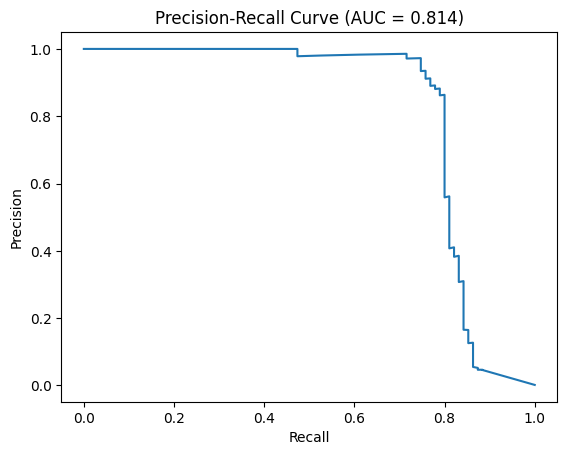

In [174]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

import matplotlib.pyplot as plt
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (AUC = {pr_auc:.3f})')
plt.show()

In [175]:
THRESHOLD=0.1

In [176]:
y_proba = pipe.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= THRESHOLD).astype(int)

In [177]:
proba_array=pd.array(y_proba)

In [178]:
proba_array.unique().shape

(481,)

In [179]:
with open('../model/fraud_model.pkl', 'wb') as f:
    pickle.dump({"model": pipe, "threshold": THRESHOLD}, f)

In [180]:
from sklearn import set_config
set_config(display='diagram')
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('trf1', ...), ('trf2', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale_amount', ...), ('passthrough_v', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [181]:
df.loc[df['Class'].values == 1, important_features + ['Amount']]

,V14,V10,V12,V4,V17,V3,V11,V16,Amount
541,-4.289254,-2.772272,-2.899907,3.997906,-2.830056,-1.609851,3.202033,-1.140747,0.00
623,-1.692029,-0.838587,-0.503141,2.288644,0.599717,1.088463,-0.414575,0.666780,529.00
4920,-1.470102,-1.525412,-6.560124,2.330243,-4.781831,-0.359745,2.032912,-2.282194,239.93
6108,-6.771097,-4.801637,-10.912819,2.679787,-12.598419,-2.592844,4.895844,-7.358083,59.00
6329,-6.079337,-2.447469,-4.609628,4.732795,6.739384,-4.304597,2.101344,2.581851,1.00
...,...,...,...,...,...,...,...,...,...
279863,-6.665177,-5.587794,-5.417424,1.749293,-4.570529,-4.518331,2.115795,-2.897825,390.00
280143,-5.210141,-3.232153,-3.096915,1.411850,-3.267116,-5.004247,2.858466,-2.155297,0.76
280149,-4.057162,-3.463891,-2.775022,0.468308,-5.035326,-2.213700,1.794969,-1.603015,77.89
281144,-6.416628,-5.245984,-5.030465,1.817092,-4.614717,-5.399730,1.933520,-2.549498,245.00


## Cross validation


In [182]:
scores = cross_val_score(pipe, X, y, cv=5, scoring='recall')
print(f"Recall per fold: {scores}")
print(f"Mean Recall: {scores.mean():.4f}")

Recall per fold: [0.86315789 0.81914894 0.64893617 0.77894737 0.71578947]
Mean Recall: 0.7652


In [185]:
def recall_at_threshold(estimator, X, y):
    probs = estimator.predict_proba(X)[:, 1]
    preds = (probs >= 0.1).astype(int)
    return recall_score(y, preds)

scores = cross_val_score(pipe, X, y, cv=cv, scoring=recall_at_threshold)

In [186]:
print(f"Recall per fold: {scores}")
print(f"Mean Recall: {scores.mean():.4f}")

Recall per fold: [0.85263158 0.86170213 0.80851064 0.84210526 0.84210526]
Mean Recall: 0.8414
